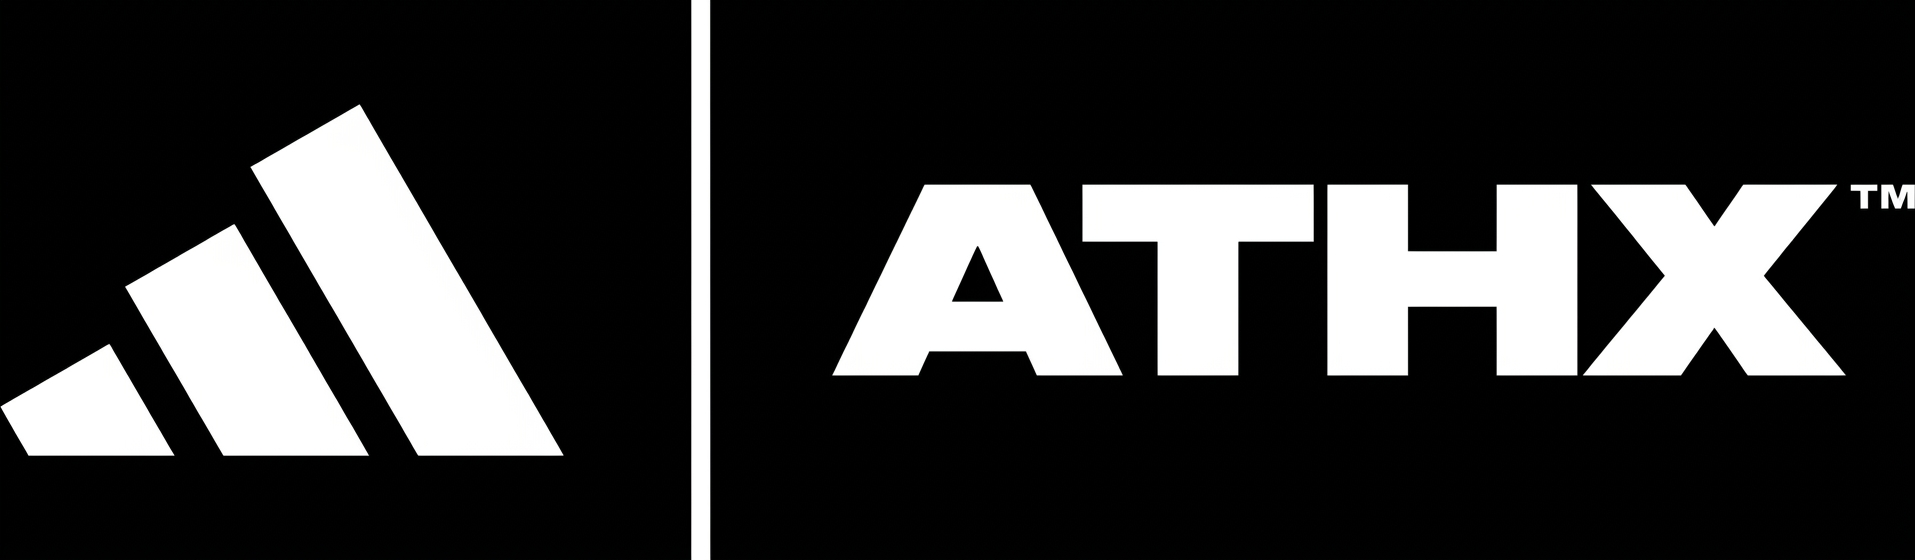

# **ATHX Marseille: performance analysis**


=== ATHX PERFORMANCE EVALUATOR ===
Enter Team Name: Veronella&Veronella
Enter Zone 1 Total Weight [Kg]: 750
Enter Zone 2 Total Distance [Km]: 10
Enter Zone 3 Time [MM:SS]: 14:00

Generating charts...


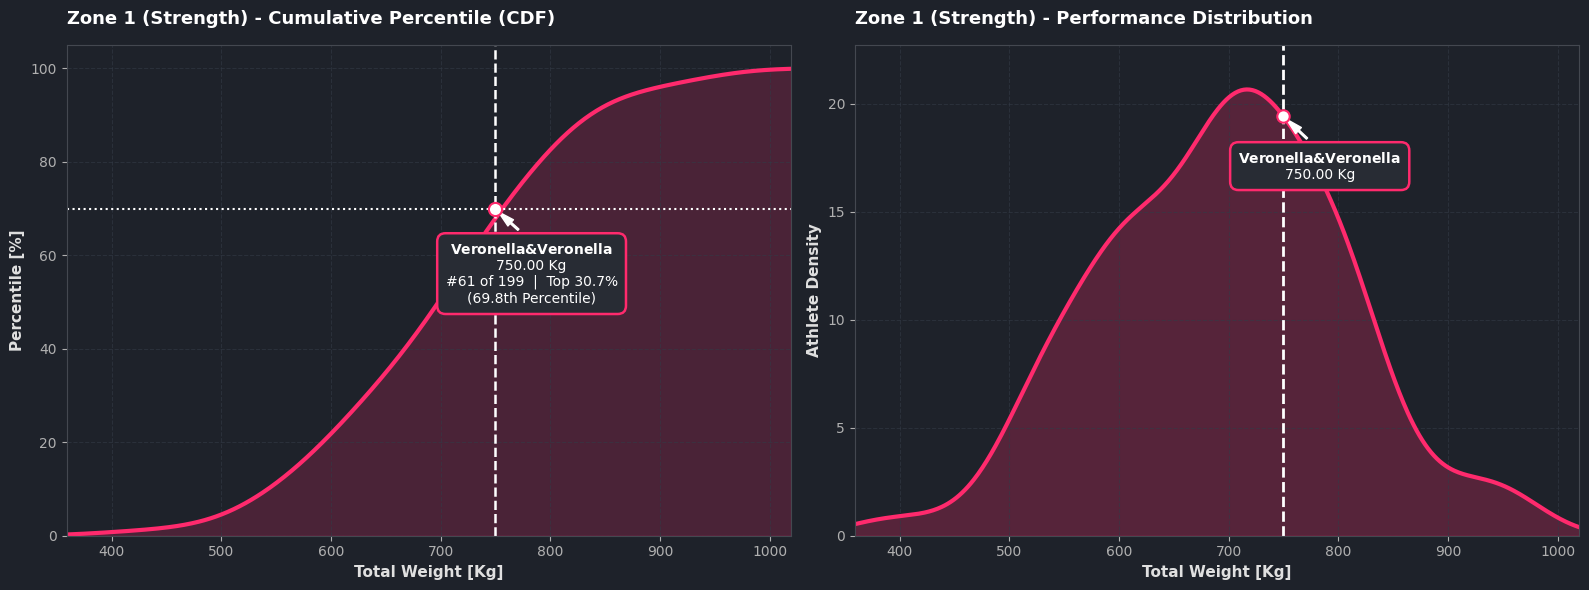

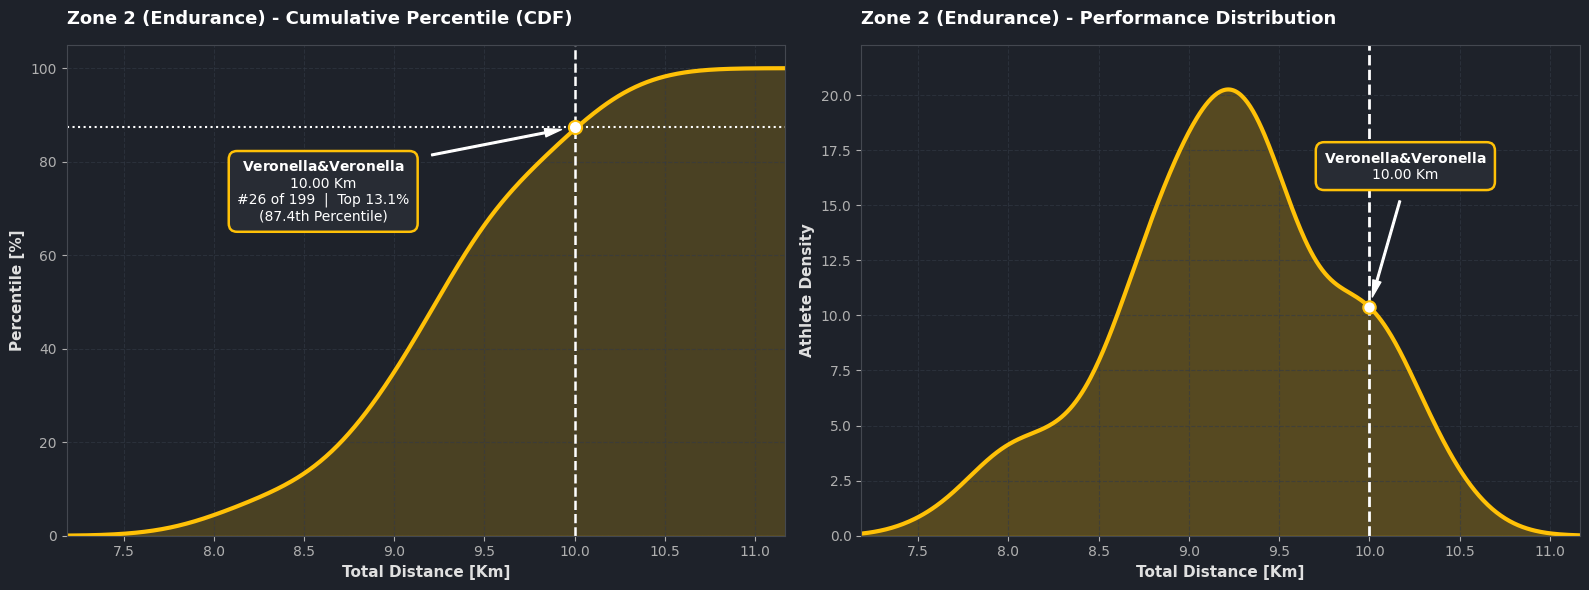

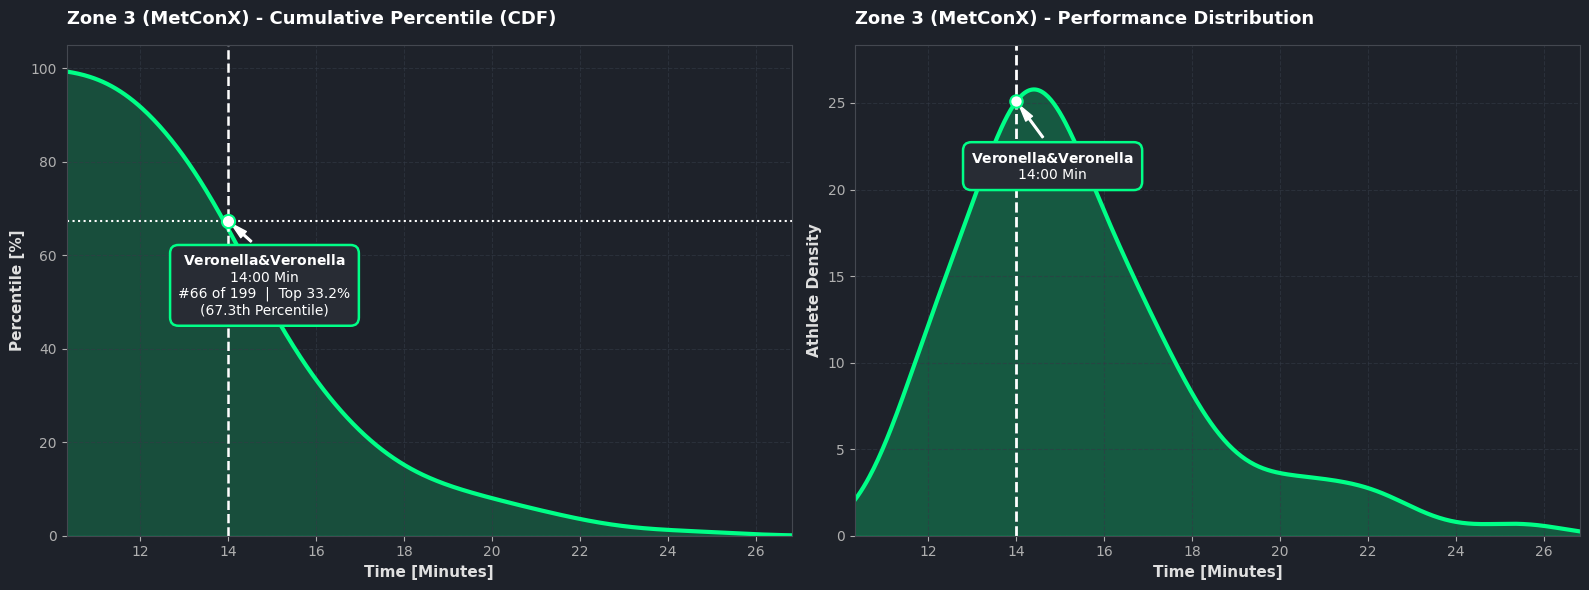

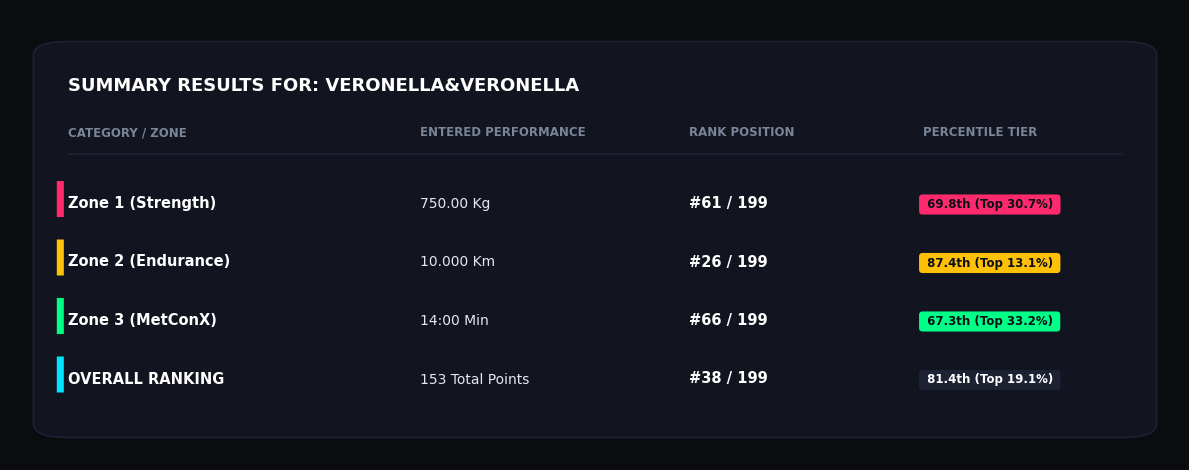

In [ ]:
# @title CODE: Cumulative Percentile(CDF) & Performance Distribution

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# ==========================================
# 1. LOAD & PREPARE DATASET
# ==========================================

# Link file raw on GitHub
url = "https://raw.githubusercontent.com/giacomomesaglio-cloud/-ATHX-Performance-Analytics-Race-Simulator/main/notebook/Classifica_ATHX_FINALE.xlsx"

df = pd.read_excel(url)


def parse_time_to_min(val):
  if pd.isna(val):
    return np.nan
  parts = str(val).strip().split(":")
  if len(parts) == 2:
    return int(parts[0]) + float(parts[1]) / 60.0
  elif len(parts) == 3:
    return int(parts[0]) * 60 + int(parts[1]) + float(parts[2]) / 60.0
  return np.nan


df["MetCon_Min"] = df["MetCon_X"].apply(parse_time_to_min)


def format_perf_display(val, unit, is_time):
  if is_time:
    if isinstance(val, str) and ":" in val:
      return f"{val} Min"
    val_float = float(val)
    m = int(val_float)
    s = int(round((val_float - m) * 60))
    if s == 60:
      m += 1
      s = 0
    return f"{m:02d}:{s:02d} Min"
  else:
    return f"{float(val):.2f} {unit}"


# ==========================================
# 2. PLOTTING FUNCTION (CDF + SMOOTH CURVE)
# ==========================================
def generate_zone_plots(
    df,
    col,
    user_val,
    zone_title,
    x_label,
    unit,
    color_neon,
    is_time=False,
    user_label="YOUR TEAM",
):
  vals = df[col].dropna().values
  val_num = parse_time_to_min(user_val) if is_time else float(user_val)
  total_athletes = len(vals)

  # Calculate Ranks & Percentiles
  if is_time:
    rank_pos = (vals < val_num).sum() + 1
    user_perc = (vals >= val_num).mean() * 100
  else:
    rank_pos = (vals > val_num).sum() + 1
    user_perc = (vals <= val_num).mean() * 100

  top_perc = (rank_pos / total_athletes) * 100

  # Smooth KDE for CDF and Density
  kde = gaussian_kde(vals)
  x_grid = np.linspace(vals.min() * 0.95, vals.max() * 1.05, 500)

  # 1. CDF Curve
  cdf = np.array([kde.integrate_box_1d(-np.inf, x) for x in x_grid]) * 100
  if is_time:
    cdf = 100 - cdf

  # 2. Smooth Density Curve
  density_y = kde(x_grid)
  bin_width = (vals.max() - vals.min()) / 20
  freq_y = density_y * total_athletes * bin_width

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor="#1e222a")

  perf_str = format_perf_display(
      user_val if is_time else val_num, unit, is_time
  )
  clean_team_label = user_label.replace(" ", "\\ ")

  # --- LEFT: CDF PERCENTILE CHART ---
  ax1.set_facecolor("#1e222a")
  ax1.plot(x_grid, cdf, color=color_neon, linewidth=3)
  ax1.fill_between(x_grid, 0, cdf, color=color_neon, alpha=0.2)
  ax1.axvline(x=val_num, color="#ffffff", linestyle="--", linewidth=1.8)
  ax1.axhline(y=user_perc, color="#ffffff", linestyle=":", linewidth=1.5)
  ax1.scatter(
      [val_num],
      [user_perc],
      color="#ffffff",
      s=90,
      zorder=5,
      edgecolor=color_neon,
      linewidth=1.5,
  )

  x_span = x_grid.max() - x_grid.min()
  x_text = (
      val_num - x_span * 0.35
      if val_num > x_grid.min() + x_span * 0.65
      else val_num + x_span * 0.05
  )
  y_text = user_perc - 20 if user_perc > 50 else user_perc + 20

  annotation_text_left = (
      f"$\\mathbf{{{clean_team_label}}}$\n"
      f"{perf_str}\n"
      f"#{rank_pos} of {total_athletes}  |  Top {top_perc:.1f}%\n"
      f"({user_perc:.1f}th Percentile)"
  )

  ax1.annotate(
      annotation_text_left,
      xy=(val_num, user_perc),
      xytext=(x_text, y_text),
      ha="center",
      arrowprops=dict(
          facecolor="#ffffff", shrink=0.08, width=1.2, headwidth=6
      ),
      color="white",
      fontsize=10,
      bbox=dict(boxstyle="round,pad=0.6", fc="#282c34", ec=color_neon, lw=1.8),
  )
  ax1.set_title(
      f"{zone_title} - Cumulative Percentile (CDF)",
      color="white",
      fontsize=13,
      weight="bold",
      loc="left",
      pad=15,
  )
  ax1.set_xlabel(x_label, color="#E0E0E0", fontsize=11, weight="bold")
  ax1.set_ylabel("Percentile [%]", color="#E0E0E0", fontsize=11, weight="bold")
  ax1.set_ylim(0, 105)
  ax1.set_xlim(x_grid.min(), x_grid.max())
  ax1.grid(True, color="#333a46", linestyle="--", alpha=0.6)
  ax1.tick_params(colors="#B0B0B0", labelsize=10)

  # --- RIGHT: SMOOTH DENSITY CURVE ---
  ax2.set_facecolor("#1e222a")
  ax2.plot(x_grid, freq_y, color=color_neon, linewidth=3)
  ax2.fill_between(x_grid, 0, freq_y, color=color_neon, alpha=0.25)
  ax2.axvline(x=val_num, color="#ffffff", linestyle="--", linewidth=2)

  user_y_density = kde(val_num)[0] * total_athletes * bin_width
  ax2.scatter(
      [val_num],
      [user_y_density],
      color="#ffffff",
      s=80,
      zorder=5,
      edgecolor=color_neon,
      linewidth=1.5,
  )

  max_freq = freq_y.max()
  annotation_text_right = f"$\\mathbf{{{clean_team_label}}}$\n{perf_str}"

  ax2.annotate(
      annotation_text_right,
      xy=(val_num, user_y_density),
      xytext=(val_num + x_span * 0.05, max_freq * 0.8),
      ha="center",
      arrowprops=dict(
          facecolor="#ffffff", shrink=0.08, width=1.2, headwidth=6
      ),
      color="white",
      fontsize=10,
      bbox=dict(boxstyle="round,pad=0.6", fc="#282c34", ec=color_neon, lw=1.8),
  )
  ax2.set_title(
      f"{zone_title} - Performance Distribution",
      color="white",
      fontsize=13,
      weight="bold",
      loc="left",
      pad=15,
  )
  ax2.set_xlabel(x_label, color="#E0E0E0", fontsize=11, weight="bold")
  ax2.set_ylabel(
      "Athlete Density", color="#E0E0E0", fontsize=11, weight="bold"
  )
  ax2.set_xlim(x_grid.min(), x_grid.max())
  ax2.set_ylim(0, max_freq * 1.1)
  ax2.grid(True, color="#333a46", linestyle="--", alpha=0.6)
  ax2.tick_params(colors="#B0B0B0", labelsize=10)

  for ax in [ax1, ax2]:
    for spine in ax.spines.values():
      spine.set_color("#444850")

  plt.tight_layout()
  plt.show()


# ==========================================
# 3. VISUAL SUMMARY TABLE CARD GENERATOR
# ==========================================
def render_summary_table_card(
    df, val_z1, val_z2, val_z3_str, team_name="YOUR TEAM"
):
  val_z3 = parse_time_to_min(val_z3_str)
  total_athletes = len(df)

  # Calculate Ranks
  rank_z1 = (df["Zone_1_tot"] > val_z1).sum() + 1
  rank_z2 = (df["Zone_2_tot"] > val_z2).sum() + 1
  rank_z3 = (df["MetCon_Min"] < val_z3).sum() + 1

  # Overall Ranking
  user_points_tot = rank_z1 + rank_z2 + rank_z3
  df_temp = df.copy()
  df_temp["temp_tot"] = (
      df_temp["points_1"] + df_temp["points_2"] + df_temp["points_3"]
  )
  rank_overall = (df_temp["temp_tot"] < user_points_tot).sum() + 1

  # Percentiles
  top_z1 = (rank_z1 / total_athletes) * 100
  top_z2 = (rank_z2 / total_athletes) * 100
  top_z3 = (rank_z3 / total_athletes) * 100
  top_overall = (rank_overall / total_athletes) * 100

  perc_z1 = ((total_athletes - rank_z1 + 1) / total_athletes) * 100
  perc_z2 = ((total_athletes - rank_z2 + 1) / total_athletes) * 100
  perc_z3 = ((total_athletes - rank_z3 + 1) / total_athletes) * 100
  perc_overall = ((total_athletes - rank_overall + 1) / total_athletes) * 100

  # Data rows for table rendering
  headers = [
      "CATEGORY / ZONE",
      "ENTERED PERFORMANCE",
      "RANK POSITION",
      "PERCENTILE TIER",
  ]
  rows = [
      [
          "Zone 1 (Strength)",
          f"{val_z1:.2f} Kg",
          f"#{rank_z1} / {total_athletes}",
          f"{perc_z1:.1f}th (Top {top_z1:.1f}%)",
      ],
      [
          "Zone 2 (Endurance)",
          f"{val_z2:.3f} Km",
          f"#{rank_z2} / {total_athletes}",
          f"{perc_z2:.1f}th (Top {top_z2:.1f}%)",
      ],
      [
          "Zone 3 (MetConX)",
          f"{val_z3_str} Min",
          f"#{rank_z3} / {total_athletes}",
          f"{perc_z3:.1f}th (Top {top_z3:.1f}%)",
      ],
      [
          "OVERALL RANKING",
          f"{user_points_tot} Total Points",
          f"#{rank_overall} / {total_athletes}",
          f"{perc_overall:.1f}th (Top {top_overall:.1f}%)",
      ],
  ]

  colors = ["#FF2A6D", "#FFC107", "#00FF87", "#00E5FF"]

  # Render Matplotlib Card Table
  plt.style.use("dark_background")
  fig, ax = plt.subplots(figsize=(12, 4.8), facecolor="#0A0C10")
  ax.set_facecolor("#0A0C10")

  # Container box
  container = patches.FancyBboxPatch(
      (0.02, 0.05),
      0.96,
      0.88,
      boxstyle="round,pad=0,rounding_size=0.03",
      facecolor="#12151F",
      edgecolor="#1D2233",
      linewidth=1.2,
      transform=ax.transAxes,
  )
  ax.add_patch(container)

  # Title
  ax.text(
      0.05,
      0.82,
      f"SUMMARY RESULTS FOR: {team_name.upper()}",
      color="#FFFFFF",
      fontsize=13,
      fontweight="bold",
      transform=ax.transAxes,
  )

  col_x = [0.05, 0.35, 0.58, 0.78]

  # Table Header
  for j, h in enumerate(headers):
    ax.text(
        col_x[j],
        0.72,
        h,
        color="#7A8599",
        fontsize=8.5,
        fontweight="bold",
        transform=ax.transAxes,
    )

  ax.plot(
      [0.05, 0.95],
      [0.68, 0.68],
      color="#1D2233",
      linewidth=1.2,
      transform=ax.transAxes,
  )

  # Rows
  y_start = 0.56
  y_step = 0.13

  for i, row in enumerate(rows):
    y = y_start - (i * y_step)

    # Accent bar
    bar = patches.FancyBboxPatch(
        (0.04, y - 0.02),
        0.006,
        0.08,
        boxstyle="round,pad=0",
        facecolor=colors[i],
        linewidth=0,
        transform=ax.transAxes,
    )
    ax.add_patch(bar)

    # Values
    ax.text(
        col_x[0],
        y,
        row[0],
        color="#FFFFFF",
        fontsize=10.5,
        fontweight="bold",
        transform=ax.transAxes,
    )
    ax.text(
        col_x[1],
        y,
        row[1],
        color="#E2E8F0",
        fontsize=10,
        fontweight="normal",
        transform=ax.transAxes,
    )
    ax.text(
        col_x[2],
        y,
        row[2],
        color="#FFFFFF",
        fontsize=10.5,
        fontweight="bold",
        transform=ax.transAxes,
    )

    # Percentile Badge
    ax.text(
        col_x[3],
        y,
        f" {row[3]} ",
        color="#0B0E14" if i < 3 else "#FFFFFF",
        fontsize=8.5,
        fontweight="bold",
        transform=ax.transAxes,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor=colors[i] if i < 3 else "#1D2233",
            edgecolor="none",
        ),
    )

  ax.axis("off")
  plt.tight_layout()
  plt.show()


# ==========================================
# 4. USER INPUT & EXECUTION
# ==========================================
print("\n=== ATHX PERFORMANCE EVALUATOR ===")
user_team_name = input("Enter Team Name: ") or "YOUR TEAM"
val_z1 = float(input("Enter Zone 1 Total Weight [Kg]: ") or 832)
val_z2 = float(input("Enter Zone 2 Total Distance [Km]: ") or 10.214)
val_z3 = input("Enter Zone 3 Time [MM:SS]: ") or "12:13"

print("\nGenerating charts...")
# Generate Plots per Zone
generate_zone_plots(
    df,
    "Zone_1_tot",
    val_z1,
    "Zone 1 (Strength)",
    "Total Weight [Kg]",
    "Kg",
    "#FF2A6D",
    user_label=user_team_name,
)
generate_zone_plots(
    df,
    "Zone_2_tot",
    val_z2,
    "Zone 2 (Endurance)",
    "Total Distance [Km]",
    "Km",
    "#FFC107",
    user_label=user_team_name,
)
generate_zone_plots(
    df,
    "MetCon_Min",
    val_z3,
    "Zone 3 (MetConX)",
    "Time [Minutes]",
    "Min",
    "#00FF87",
    is_time=True,
    user_label=user_team_name,
)

# Render Visual Summary Card Table
render_summary_table_card(
    df, val_z1, val_z2, val_z3, team_name=user_team_name
)

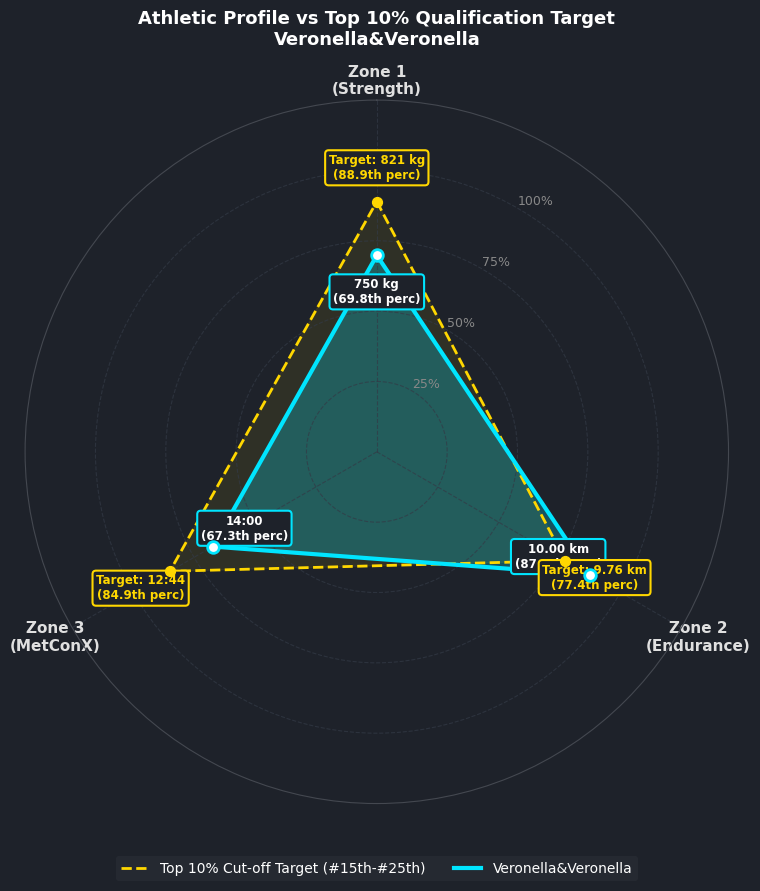

In [15]:
# @title CODE: Radar Chart - Athletic profile vs Top10%

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load dataset and parse execution times
df = pd.read_excel('Classifica_ATHX_FINALE.xlsx')

def parse_time_to_min(val):
    if pd.isna(val): return np.nan
    parts = str(val).strip().split(':')
    if len(parts) == 2:
        return int(parts[0]) + float(parts[1]) / 60.0
    elif len(parts) == 3:
        return int(parts[0]) * 60 + int(parts[1]) + float(parts[2]) / 60.0
    return np.nan

def format_min_to_time(minutes):
    if pd.isna(minutes): return "N/A"
    mins = int(minutes)
    secs = int(round((minutes - mins) * 60))
    if secs == 60:
        mins += 1
        secs = 0
    return f"{mins:02d}:{secs:02d}"

df['MetCon_Min'] = df['MetCon_X'].apply(parse_time_to_min)

# =========================================================
# 2. DYNAMIC CUT-OFF CLUSTER CALCULATION (TOP 10% TARGET)
# =========================================================
total_teams = len(df)
target_percentage = 0.10  # Top 10%

# Calcolo dinamico della posizione target principale
target_rank = max(1, int(round(total_teams * target_percentage)))

# Definizione dinamica della finestra del cluster (±2.5% dei partecipanti totali, min 2 posizioni)
cluster_window = max(2, int(round(total_teams * 0.025)))
min_rank = max(1, target_rank - cluster_window)
max_rank = min(total_teams, target_rank + cluster_window)

# Filtraggio del cluster dinamico attorno alla posizione Top 10%
cutoff_cluster_df = df[(df['rank'] >= min_rank) & (df['rank'] <= max_rank)]

# Calcolo delle medie del cluster target per ciascuna zona
mean_target_z1 = cutoff_cluster_df['Zone_1_tot'].mean()
mean_target_z2 = cutoff_cluster_df['Zone_2_tot'].mean()
mean_target_z3 = cutoff_cluster_df['MetCon_Min'].mean()

# Conversione dei valori medi in percentili generali della popolazione
perc_target_z1 = (df['Zone_1_tot'] <= mean_target_z1).mean() * 100
perc_target_z2 = (df['Zone_2_tot'] <= mean_target_z2).mean() * 100
perc_target_z3 = (df['MetCon_Min'] >= mean_target_z3).mean() * 100


# =========================================================
# 3. RADAR CHART GENERATION (USER VS CUT-OFF TARGET)
# =========================================================
def generate_radar_chart(df, val_z1, val_z2, val_z3_str, team_name):
    val_z3 = parse_time_to_min(val_z3_str)

    # Calculate user percentiles
    perc_user_z1 = (df['Zone_1_tot'] <= val_z1).mean() * 100
    perc_user_z2 = (df['Zone_2_tot'] <= val_z2).mean() * 100
    perc_user_z3 = (df['MetCon_Min'] >= val_z3).mean() * 100

    categories = ['Zone 1\n(Strength)', 'Zone 2\n(Endurance)', 'Zone 3\n(MetConX)']

    values_user = [perc_user_z1, perc_user_z2, perc_user_z3]
    values_target = [perc_target_z1, perc_target_z2, perc_target_z3]

    raw_user_labels = [f"{val_z1:.0f} kg", f"{val_z2:.2f} km", val_z3_str]
    raw_target_labels = [f"{mean_target_z1:.0f} kg", f"{mean_target_z2:.2f} km", format_min_to_time(mean_target_z3)]

    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    values_user_closed = values_user + values_user[:1]
    values_target_closed = values_target + values_target[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True), facecolor='#1e222a')
    ax.set_facecolor('#1e222a')

    # North top orientation and clockwise direction
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    plt.xticks(angles[:-1], categories, color='#E0E0E0', size=11, weight='bold')
    ax.set_rlabel_position(30)
    plt.yticks([25, 50, 75, 100], ["25%", "50%", "75%", "100%"], color="#888888", size=9)
    plt.ylim(0, 125)

    ax.grid(color='#333a46', linestyle='--', alpha=0.7)
    ax.spines['polar'].set_color('#444850')

    # Label dinamica per il target
    target_label = f'Top 10% Cut-off Target (#{min_rank}th-#{max_rank}th)'

    # Plot Top 10% Cut-off Target line (Giallino tratteggiato)
    ax.plot(angles, values_target_closed, color='#FFD700', linewidth=2, linestyle='--', label=target_label)
    ax.fill(angles, values_target_closed, color='#FFD700', alpha=0.08)
    ax.scatter(angles[:-1], values_target, color='#FFD700', s=50, zorder=4)

    # Plot User performance line (Azzurro continuo in evidenza)
    ax.plot(angles, values_user_closed, color='#00E5FF', linewidth=3, linestyle='solid', label=team_name)
    ax.fill(angles, values_user_closed, color='#00E5FF', alpha=0.25)
    ax.scatter(angles[:-1], values_user, color='#ffffff', s=70, zorder=5, edgecolor='#00E5FF', linewidth=2)

    # --- ANNOTATIONS ---
    # User Annotations
    user_positions = [(angles[0], values_user[0] - 13), (angles[1], values_user[1] - 13), (angles[2], values_user[2] - 13)]
    for (angle, r_pos), val_p, val_raw in zip(user_positions, values_user, raw_user_labels):
        ax.annotate(
            f"{val_raw}\n({val_p:.1f}th perc)",
            xy=(angle, r_pos),
            ha='center', va='center', color='white', weight='bold', fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="#1e222a", ec="#00E5FF", lw=1.5)
        )

    # Cut-off Target Annotations
    target_positions = [(angles[0], values_target[0] + 12), (angles[1], values_target[1] + 12), (angles[2], values_target[2] + 12)]
    for (angle, r_pos), val_p, val_raw in zip(target_positions, values_target, raw_target_labels):
        ax.annotate(
            f"Target: {val_raw}\n({val_p:.1f}th perc)",
            xy=(angle, r_pos),
            ha='center', va='center', color='#FFD700', weight='bold', fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="#1e222a", ec="#FFD700", lw=1.5)
        )

    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True, facecolor='#282c34', edgecolor='none', labelcolor='white', fontsize=10)
    plt.title(f"Athletic Profile vs Top 10% Qualification Target\n{team_name}", color='white', fontsize=13, weight='bold', pad=40)

    plt.tight_layout()
    plt.show()

# Execution
generate_radar_chart(df, val_z1, val_z2, val_z3, user_team_name)

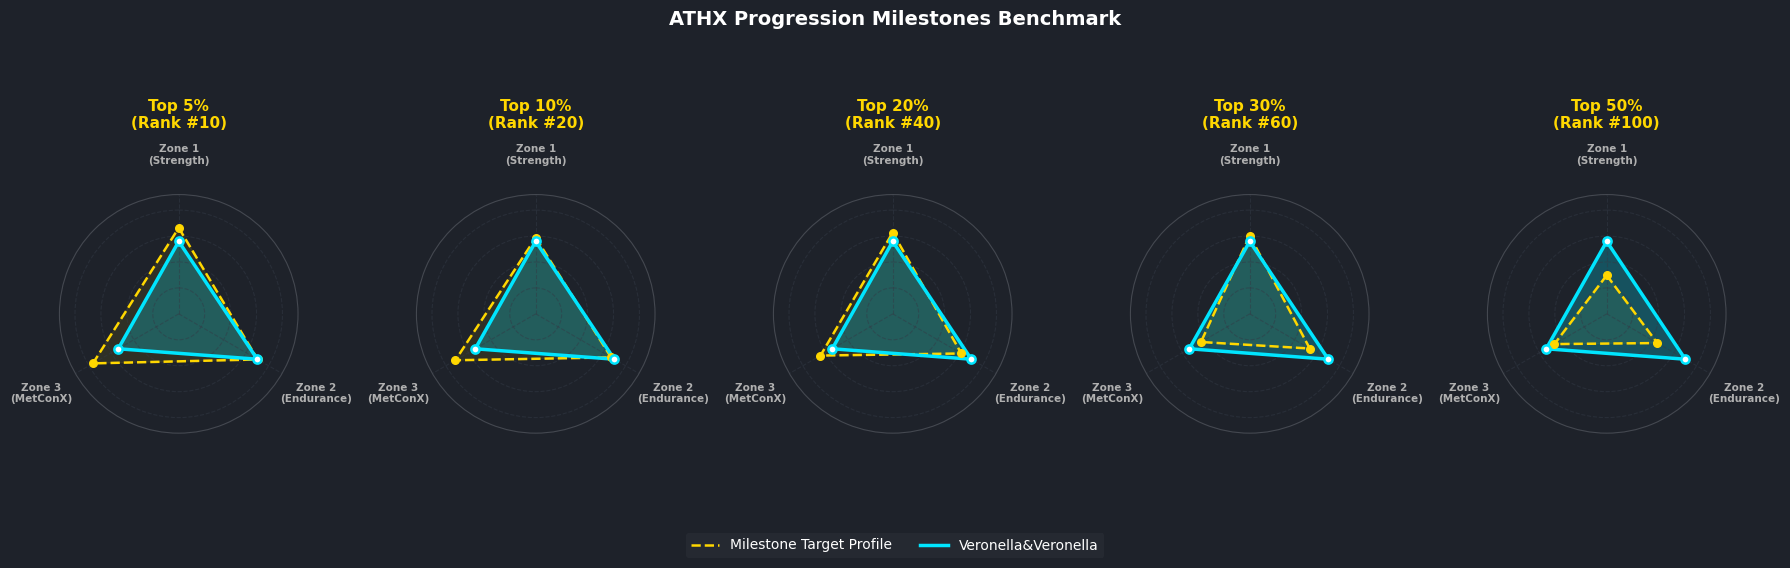

In [16]:
# @title CODE: ATHX Progression Mailestones Benchmark

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# DYNAMIC MILESTONES GRID (CONSISTENT STYLE WITH MAIN RADAR)
# =========================================================
def generate_milestone_radar_grid(df, val_z1, val_z2, val_z3_str, team_name):
    val_z3 = parse_time_to_min(val_z3_str)

    # Percentili del vostro team
    perc_user_z1 = (df['Zone_1_tot'] <= val_z1).mean() * 100
    perc_user_z2 = (df['Zone_2_tot'] <= val_z2).mean() * 100
    perc_user_z3 = (df['MetCon_Min'] >= val_z3).mean() * 100

    values_user = [perc_user_z1, perc_user_z2, perc_user_z3]
    values_user_closed = values_user + values_user[:1]

    target_pcts = [5, 10, 20, 30, 50]
    total_teams = len(df)

    categories = ['Zone 1\n(Strength)', 'Zone 2\n(Endurance)', 'Zone 3\n(MetConX)']
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, axes = plt.subplots(1, 5, figsize=(18, 5.0), subplot_kw=dict(polar=True), facecolor='#1e222a')

    for idx, pct in enumerate(target_pcts):
        ax = axes[idx]
        ax.set_facecolor('#1e222a')

        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, color='#B0B0B0', size=7.5, weight='bold')
        ax.tick_params(axis='x', pad=18)

        ax.set_rlabel_position(0)
        ax.set_yticks([25, 50, 75, 100])
        ax.set_yticklabels([])
        ax.set_ylim(0, 115)

        ax.grid(color='#333a46', linestyle='--', alpha=0.5)
        ax.spines['polar'].set_color('#444850')

        # Calcolo dinamico posizione in classifica
        calculated_rank = max(1, int(round((pct / 100.0) * total_teams)))

        # Micro-cluster attorno al rank (±2 posizioni)
        min_r = max(1, calculated_rank - 2)
        max_r = min(total_teams, calculated_rank + 2)
        cluster_df = df[(df['rank'] >= min_r) & (df['rank'] <= max_r)]

        m_z1 = cluster_df['Zone_1_tot'].mean()
        m_z2 = cluster_df['Zone_2_tot'].mean()
        m_z3 = cluster_df['MetCon_Min'].mean()

        p_z1 = (df['Zone_1_tot'] <= m_z1).mean() * 100
        p_z2 = (df['Zone_2_tot'] <= m_z2).mean() * 100
        p_z3 = (df['MetCon_Min'] >= m_z3).mean() * 100

        vals_team = [p_z1, p_z2, p_z3]
        vals_team_closed = vals_team + vals_team[:1]

        # 1. Milestone Target Profile (Giallino Tratteggiato)
        ax.plot(angles, vals_team_closed, color='#FFD700', linewidth=1.8, linestyle='--', label='Milestone Target Profile' if idx == 0 else "")
        ax.fill(angles, vals_team_closed, color='#FFD700', alpha=0.08)
        ax.scatter(angles[:-1], vals_team, color='#FFD700', s=30, zorder=4)

        # 2. Your Team Profile (Azzurro Continuo in Evidenza)
        ax.plot(angles, values_user_closed, color='#00E5FF', linewidth=2.5, linestyle='solid', label=team_name if idx == 0 else "")
        ax.fill(angles, values_user_closed, color='#00E5FF', alpha=0.25)
        ax.scatter(angles[:-1], values_user, color='#ffffff', s=35, zorder=5, edgecolor='#00E5FF', linewidth=1.8)

        ax.set_title(f"Top {pct}%\n(Rank #{calculated_rank})", color='#FFD700', fontsize=11, weight='bold', pad=48)

    fig.legend(
        loc='lower center', bbox_to_anchor=(0.5, -0.06), ncol=2,
        frameon=True, facecolor='#282c34', edgecolor='none', labelcolor='white', fontsize=10
    )

    plt.suptitle("ATHX Progression Milestones Benchmark", color='white', fontsize=14, weight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Esecuzione
generate_milestone_radar_grid(df, val_z1, val_z2, val_z3, user_team_name)

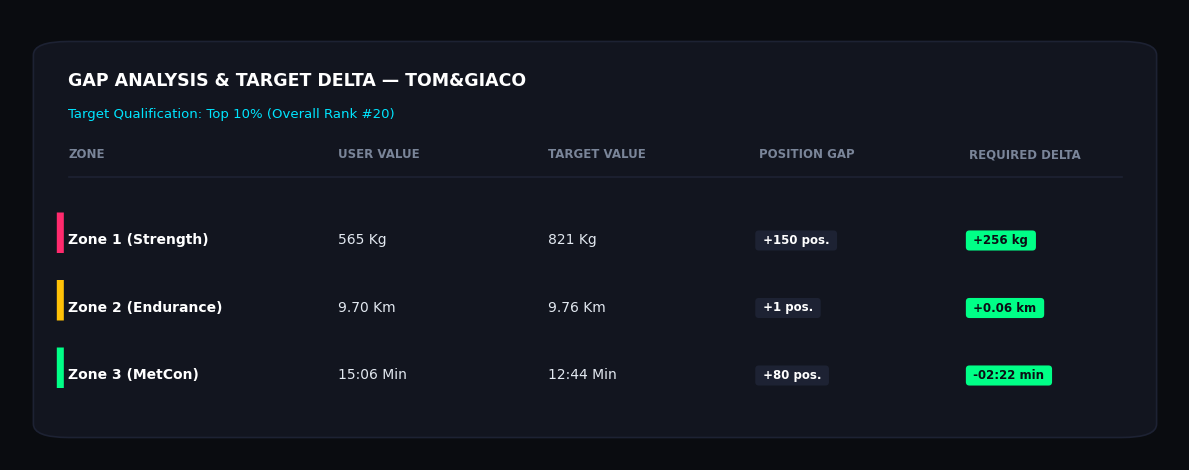

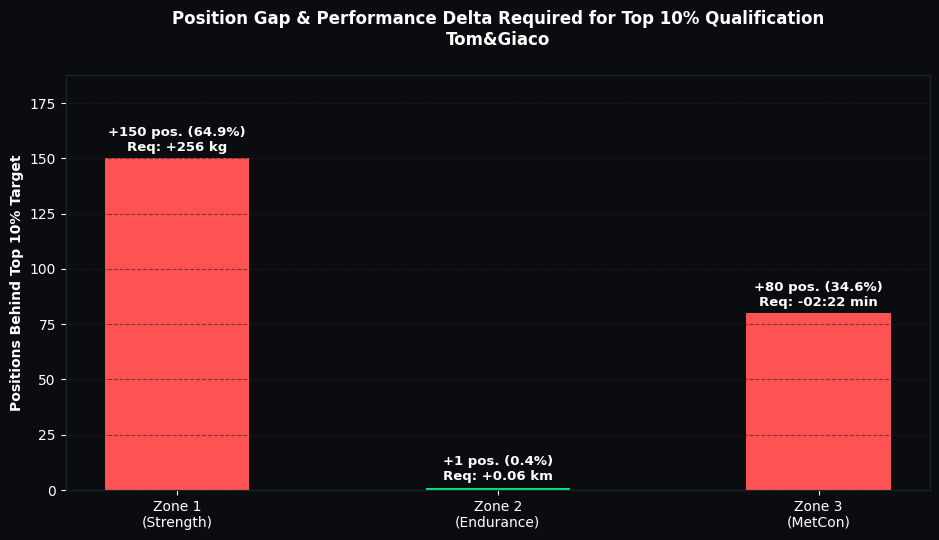

In [ ]:
# @title CODE: Gap Analysis - Target benchmark 10%

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Helper functions
def parse_time_to_min(val):
  if pd.isna(val):
    return np.nan
  parts = str(val).strip().split(':')
  if len(parts) == 2:
    return int(parts[0]) + float(parts[1]) / 60.0
  elif len(parts) == 3:
    return int(parts[0]) * 60 + int(parts[1]) + float(parts[2]) / 60.0
  return np.nan


def format_min_to_time(minutes_val):
  mins = int(minutes_val)
  secs = int(round((minutes_val - mins) * 60))
  if secs == 60:
    mins += 1
    secs = 0
  return f'{mins:02d}:{secs:02d}'


# ==========================================
# VISUAL GAP ANALYSIS CARD GENERATOR
# ==========================================
def render_gap_analysis_card(
    team_name,
    target_perc,
    target_rank,
    val_z1,
    target_z1,
    gap_z1,
    delta_z1_str,
    val_z2,
    target_z2,
    gap_z2,
    delta_z2_str,
    val_z3_str,
    target_z3,
    gap_z3,
    delta_z3_str,
):
  """Renders a sleek, modern UI card table displaying Gap Analysis & Target Deltas."""
  plt.style.use('dark_background')
  fig, ax = plt.subplots(figsize=(12, 4.8), facecolor='#0A0C10')
  ax.set_facecolor('#0A0C10')

  # Outer Box Container
  container = patches.FancyBboxPatch(
      (0.02, 0.05),
      0.96,
      0.88,
      boxstyle='round,pad=0,rounding_size=0.03',
      facecolor='#12151F',
      edgecolor='#1D2233',
      linewidth=1.2,
      transform=ax.transAxes,
  )
  ax.add_patch(container)

  # Header Title & Subtitle
  ax.text(
      0.05,
      0.83,
      f'GAP ANALYSIS & TARGET DELTA — {team_name.upper()}',
      color='#FFFFFF',
      fontsize=12.5,
      fontweight='bold',
      transform=ax.transAxes,
  )
  ax.text(
      0.05,
      0.76,
      f'Target Qualification: Top {int(target_perc*100)}% (Overall Rank'
      f' #{target_rank})',
      color='#00E5FF',
      fontsize=9.5,
      fontweight='normal',
      transform=ax.transAxes,
  )

  # Table Headers & Column Positions
  headers = [
      'ZONE',
      'USER VALUE',
      'TARGET VALUE',
      'POSITION GAP',
      'REQUIRED DELTA',
  ]
  col_x = [0.05, 0.28, 0.46, 0.64, 0.82]

  for j, h in enumerate(headers):
    ax.text(
        col_x[j],
        0.67,
        h,
        color='#7A8599',
        fontsize=8.5,
        fontweight='bold',
        transform=ax.transAxes,
    )

  # Separator Line
  ax.plot(
      [0.05, 0.95],
      [0.63, 0.63],
      color='#1D2233',
      linewidth=1.2,
      transform=ax.transAxes,
  )

  # Table Data Rows
  rows = [
      [
          'Zone 1 (Strength)',
          f'{val_z1:.0f} Kg',
          f'{target_z1:.0f} Kg',
          f'+{gap_z1} pos.',
          delta_z1_str,
      ],
      [
          'Zone 2 (Endurance)',
          f'{val_z2:.2f} Km',
          f'{target_z2:.2f} Km',
          f'+{gap_z2} pos.',
          delta_z2_str,
      ],
      [
          'Zone 3 (MetCon)',
          f'{val_z3_str} Min',
          f'{format_min_to_time(target_z3)} Min',
          f'+{gap_z3} pos.',
          delta_z3_str,
      ],
  ]

  colors = ['#FF2A6D', '#FFC107', '#00FF87']
  y_start = 0.48
  y_step = 0.15

  for i, row in enumerate(rows):
    y = y_start - (i * y_step)

    # Zone Color Accent Bar
    bar = patches.FancyBboxPatch(
        (0.04, y - 0.02),
        0.006,
        0.09,
        boxstyle='round,pad=0',
        facecolor=colors[i],
        linewidth=0,
        transform=ax.transAxes,
    )
    ax.add_patch(bar)

    # Text Columns
    ax.text(
        col_x[0],
        y,
        row[0],
        color='#FFFFFF',
        fontsize=10,
        fontweight='bold',
        transform=ax.transAxes,
    )
    ax.text(
        col_x[1],
        y,
        row[1],
        color='#E2E8F0',
        fontsize=10,
        fontweight='normal',
        transform=ax.transAxes,
    )
    ax.text(
        col_x[2],
        y,
        row[2],
        color='#E2E8F0',
        fontsize=10,
        fontweight='normal',
        transform=ax.transAxes,
    )

    # Pos Gap Badge
    ax.text(
        col_x[3],
        y,
        f' {row[3]} ',
        color='#FFFFFF',
        fontsize=8.5,
        fontweight='bold',
        transform=ax.transAxes,
        bbox=dict(
            boxstyle='round,pad=0.3', facecolor='#1D2233', edgecolor='none'
        ),
    )

    # Required Delta Badge (Highlighted in Cyan or Grey if Met)
    delta_is_met = 'Target Met' in row[4]
    ax.text(
        col_x[4],
        y,
        f' {row[4]} ',
        color='#0B0E14' if not delta_is_met else '#A0AABB',
        fontsize=8.5,
        fontweight='bold',
        transform=ax.transAxes,
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='#00FF87' if not delta_is_met else '#1D2233',
            edgecolor='none',
        ),
    )

  ax.axis('off')
  plt.tight_layout()
  plt.show()


# ==========================================
# MAIN ANALYSIS FUNCTION
# ==========================================
def analyze_gap_to_target(
    df, val_z1, val_z2, val_z3_str, team_name, target_perc=0.10
):
  val_z3 = parse_time_to_min(val_z3_str)
  total_teams = len(df)

  # 1. Dynamic Target Calculation (Top 10% Cluster Target)
  target_rank = max(1, int(round(total_teams * target_perc)))
  cluster_window = max(2, int(round(total_teams * 0.025)))
  min_rank = max(1, target_rank - cluster_window)
  max_rank = min(total_teams, target_rank + cluster_window)

  cutoff_cluster = df[(df['rank'] >= min_rank) & (df['rank'] <= max_rank)]

  target_z1 = cutoff_cluster['Zone_1_tot'].mean()
  target_z2 = cutoff_cluster['Zone_2_tot'].mean()
  target_z3 = cutoff_cluster['MetCon_Min'].mean()

  # 2. Zone Partial Ranks (1-based)
  rank_user_z1 = (df['Zone_1_tot'] > val_z1).sum() + 1
  rank_user_z2 = (df['Zone_2_tot'] > val_z2).sum() + 1
  rank_user_z3 = (df['MetCon_Min'] < val_z3).sum() + 1

  rank_target_z1 = (df['Zone_1_tot'] > target_z1).sum() + 1
  rank_target_z2 = (df['Zone_2_tot'] > target_z2).sum() + 1
  rank_target_z3 = (df['MetCon_Min'] < target_z3).sum() + 1

  # 3. Position Gaps
  gap_z1 = rank_user_z1 - rank_target_z1
  gap_z2 = rank_user_z2 - rank_target_z2
  gap_z3 = rank_user_z3 - rank_target_z3

  total_gap = max(1, gap_z1 + gap_z2 + gap_z3)

  # Gap Percent Impact
  pct_gap_z1 = max(0, (gap_z1 / total_gap) * 100)
  pct_gap_z2 = max(0, (gap_z2 / total_gap) * 100)
  pct_gap_z3 = max(0, (gap_z3 / total_gap) * 100)

  # 4. Raw Performance Delta Required to Hit Target
  delta_z1 = target_z1 - val_z1
  delta_z2 = target_z2 - val_z2
  delta_z3_min = val_z3 - target_z3

  delta_z1_str = f'+{delta_z1:.0f} kg' if delta_z1 > 0 else 'Target Met'
  delta_z2_str = f'+{delta_z2:.2f} km' if delta_z2 > 0 else 'Target Met'
  delta_z3_str = (
      f'-{format_min_to_time(delta_z3_min)} min'
      if delta_z3_min > 0
      else 'Target Met'
  )

  # 5. Render Graphical UI Summary Card Table
  render_gap_analysis_card(
      team_name,
      target_perc,
      target_rank,
      val_z1,
      target_z1,
      gap_z1,
      delta_z1_str,
      val_z2,
      target_z2,
      gap_z2,
      delta_z2_str,
      val_z3_str,
      target_z3,
      gap_z3,
      delta_z3_str,
  )

  # 6. Position Gap Bar Chart Generation
  categories = [
      'Zone 1\n(Strength)',
      'Zone 2\n(Endurance)',
      'Zone 3\n(MetCon)',
  ]
  gaps = [gap_z1, gap_z2, gap_z3]
  pcts = [pct_gap_z1, pct_gap_z2, pct_gap_z3]
  deltas = [delta_z1_str, delta_z2_str, delta_z3_str]

  colors = [
      '#FF5252' if g > 40 else '#FFD700' if g > 15 else '#00E676' for g in gaps
  ]

  fig, ax = plt.subplots(figsize=(9.5, 5.5), facecolor='#0A0C10')
  ax.set_facecolor('#0A0C10')

  bars = ax.bar(categories, gaps, color=colors, width=0.45, edgecolor='none')

  for bar, gap, pct, delta in zip(bars, gaps, pcts, deltas):
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 2,
        f'+{gap} pos. ({pct:.1f}%)\nReq: {delta}',
        ha='center',
        va='bottom',
        color='white',
        weight='bold',
        fontsize=9.5,
    )

  ax.set_ylabel(
      f'Positions Behind Top {int(target_perc*100)}% Target',
      color='white',
      fontsize=10,
      weight='bold',
  )
  ax.tick_params(colors='white', labelsize=10)
  ax.grid(color='#1D2233', linestyle='--', alpha=0.6, axis='y')
  ax.set_ylim(0, max(gaps) * 1.25 if max(gaps) > 0 else 10)

  for spine in ax.spines.values():
    spine.set_color('#1D2233')

  plt.title(
      f'Position Gap & Performance Delta Required for Top'
      f' {int(target_perc*100)}% Qualification\n{team_name}',
      color='white',
      fontsize=12,
      weight='bold',
      pad=22,
  )

  plt.tight_layout()
  plt.show()


# Execution
analyze_gap_to_target(df, val_z1, val_z2, val_z3, user_team_name)

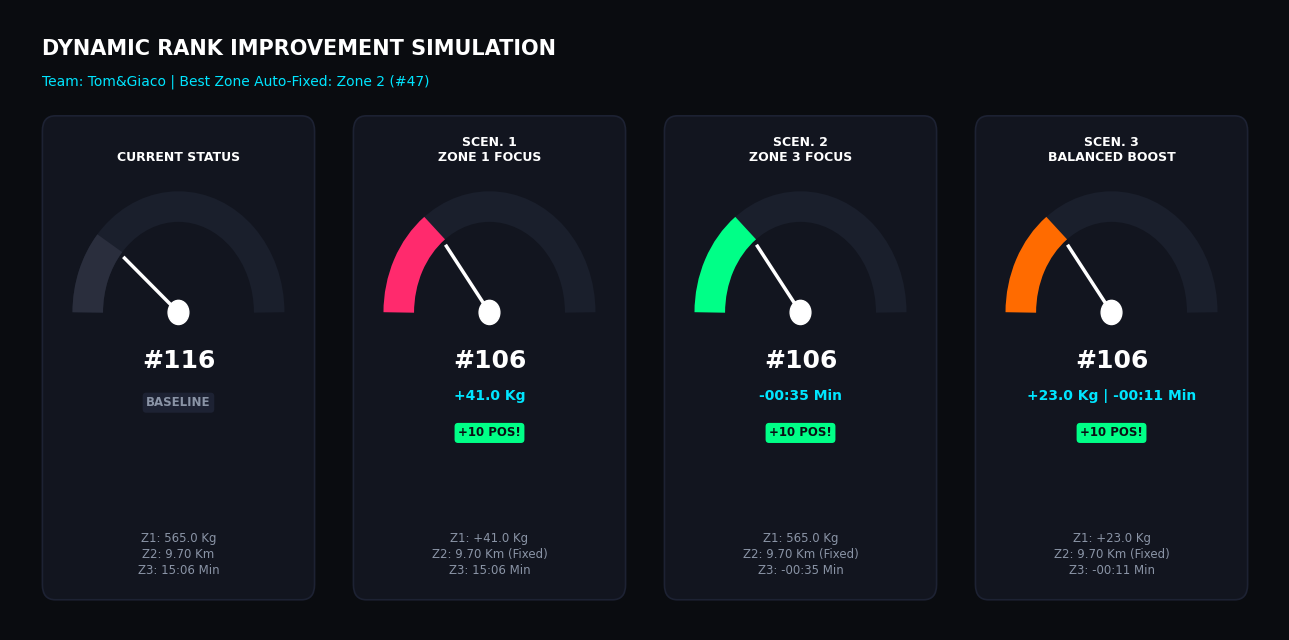

In [ ]:
# @title CODE: Rank improvement Analysis

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def run_real_rank_simulation(
    df,
    user_team_name,
    val_z1,
    val_z2,
    val_z3_min,
    target_positions_gain=10,
    max_scale_rank=150,
):
  """Calculates required physical improvements based on the dataset (df) by automatically

  detecting and fixing the team's best performing zone, then renders a circular
  radial gauge dashboard with custom zone palette (Zone 1: Pink, Zone 2:
  Yellow, Zone 3: Green, Balanced: Neon Orange).
  """
  # 1. Zone Color Palette
  COLOR_BASELINE = "#2A2E3D"
  COLOR_ZONE1 = "#FF2A6D"  # Neon Pink / Strength
  COLOR_ZONE2 = "#FFC107"  # Amber Yellow / Endurance
  COLOR_ZONE3 = "#00FF87"  # Neon Green / MetCon
  COLOR_BALANCED = "#FF6B00"  # Neon Orange Fluo / Balanced Boost

  # Helper for MM:SS time formatting
  def format_min_to_mmss(minutes_val):
    mins = int(minutes_val)
    secs = int(round((minutes_val - mins) * 60))
    return f"{mins:02d}:{secs:02d}"

  # 2. Duplicate DataFrame to prevent modifying original data
  df_sim = df.copy()

  # Calculate baseline ranks across all teams
  df_sim["r1"] = df_sim["Zone_1_tot"].rank(ascending=False, method="min")
  df_sim["r2"] = df_sim["Zone_2_tot"].rank(ascending=False, method="min")
  df_sim["r3"] = df_sim["MetCon_Min"].rank(ascending=True, method="min")
  df_sim["total_points"] = df_sim["r1"] + df_sim["r2"] + df_sim["r3"]
  df_sim["overall_rank"] = df_sim["total_points"].rank(
      ascending=True, method="min"
  )

  # Extract or inject user team baseline
  team_row = df_sim[
      df_sim["team"].str.contains(user_team_name, case=False, na=False)
  ]

  if team_row.empty:
    current_r1 = (df_sim["Zone_1_tot"] > val_z1).sum() + 1
    current_r2 = (df_sim["Zone_2_tot"] > val_z2).sum() + 1
    current_r3 = (df_sim["MetCon_Min"] < val_z3_min).sum() + 1
    current_pts = current_r1 + current_r2 + current_r3
    current_rank = int((df_sim["total_points"] < current_pts).sum() + 1)
  else:
    current_r1 = int(team_row["r1"].values[0])
    current_r2 = int(team_row["r2"].values[0])
    current_r3 = int(team_row["r3"].values[0])
    current_pts = int(team_row["total_points"].values[0])
    current_rank = int(team_row["overall_rank"].values[0])

  # 3. AUTOMATICALLY DETECT BEST ZONE TO FIX
  zone_ranks = {1: current_r1, 2: current_r2, 3: current_r3}
  best_zone = min(
      zone_ranks, key=zone_ranks.get
  )  # Zone with lowest (best) rank number
  target_zones = [z for z in [1, 2, 3] if z != best_zone]

  # Target overall rank & needed points
  target_rank = max(1, current_rank - target_positions_gain)
  target_pts = df_sim[df_sim["overall_rank"] <= target_rank][
      "total_points"
  ].max()
  pts_needed_delta = current_pts - target_pts

  # Pre-sort distributions for dynamic threshold lookup
  z1_sorted = df_sim["Zone_1_tot"].sort_values(ascending=False).values
  z2_sorted = df_sim["Zone_2_tot"].sort_values(ascending=False).values
  z3_sorted = df_sim["MetCon_Min"].sort_values(ascending=True).values

  def calc_zone_improvement(zone_idx, points_delta):
    """Calculates delta required for a specific zone given a target rank reduction."""
    if zone_idx == 1:
      req_r = max(1, current_r1 - points_delta)
      req_val = z1_sorted[int(req_r) - 1]
      delta = max(0.0, req_val - val_z1)
      return f"+{delta:.1f} Kg", f"Z1: +{delta:.1f} Kg"
    elif zone_idx == 2:
      req_r = max(1, current_r2 - points_delta)
      req_val = z2_sorted[int(req_r) - 1]
      delta = max(0.0, req_val - val_z2)
      return f"+{delta:.2f} Km", f"Z2: +{delta:.2f} Km"
    elif zone_idx == 3:
      req_r = max(1, current_r3 - points_delta)
      req_val = z3_sorted[int(req_r) - 1]
      delta = max(0.0, val_z3_min - req_val)
      return (
          f"-{format_min_to_mmss(delta)} Min",
          f"Z3: -{format_min_to_mmss(delta)} Min",
      )

  # Define Zone Baseline Strings
  base_z_strings = {
      1: f"Z1: {val_z1:.1f} Kg",
      2: f"Z2: {val_z2:.2f} Km",
      3: f"Z3: {format_min_to_mmss(val_z3_min)} Min",
  }

  z_a, z_b = target_zones[0], target_zones[1]

  # Scenario 1: Focus on variable target zone A
  prim_a, det_a = calc_zone_improvement(z_a, pts_needed_delta)
  details_scen1 = (
      f"{det_a if z_a==1 else (base_z_strings[1] + (' (Fixed)' if best_zone==1 else ''))}\n"
      f"{det_a if z_a==2 else (base_z_strings[2] + (' (Fixed)' if best_zone==2 else ''))}\n"
      f"{det_a if z_a==3 else (base_z_strings[3] + (' (Fixed)' if best_zone==3 else ''))}"
  )

  # Scenario 2: Focus on variable target zone B
  prim_b, det_b = calc_zone_improvement(z_b, pts_needed_delta)
  details_scen2 = (
      f"{det_b if z_b==1 else (base_z_strings[1] + (' (Fixed)' if best_zone==1 else ''))}\n"
      f"{det_b if z_b==2 else (base_z_strings[2] + (' (Fixed)' if best_zone==2 else ''))}\n"
      f"{det_b if z_b==3 else (base_z_strings[3] + (' (Fixed)' if best_zone==3 else ''))}"
  )

  # Scenario 3: Balanced Boost between both target zones
  half_pts = int(np.ceil(pts_needed_delta / 2.0))
  prim_bal_a, det_bal_a = calc_zone_improvement(z_a, half_pts)
  prim_bal_b, det_bal_b = calc_zone_improvement(z_b, half_pts)

  prim_bal_combined = f"{prim_bal_a} | {prim_bal_b}"
  details_scen3 = (
      f"{det_bal_a if z_a==1 else (det_bal_b if z_b==1 else (base_z_strings[1] + (' (Fixed)' if best_zone==1 else '')))}\n"
      f"{det_bal_a if z_a==2 else (det_bal_b if z_b==2 else (base_z_strings[2] + (' (Fixed)' if best_zone==2 else '')))}\n"
      f"{det_bal_a if z_a==3 else (det_bal_b if z_b==3 else (base_z_strings[3] + (' (Fixed)' if best_zone==3 else '')))}"
  )

  # Map Scenario Colors
  zone_colors = {1: COLOR_ZONE1, 2: COLOR_ZONE2, 3: COLOR_ZONE3}

  scenarios_data = [
      {
          "title": "CURRENT STATUS",
          "rank": current_rank,
          "badge": "BASELINE",
          "primary_change": "",
          "details": (
              f"{base_z_strings[1]}\n{base_z_strings[2]}\n{base_z_strings[3]}"
          ),
          "color": COLOR_BASELINE,
      },
      {
          "title": f"SCEN. 1\nZONE {z_a} FOCUS",
          "rank": target_rank,
          "badge": f"+{current_rank - target_rank} POS!",
          "primary_change": prim_a,
          "details": details_scen1,
          "color": zone_colors[z_a],
      },
      {
          "title": f"SCEN. 2\nZONE {z_b} FOCUS",
          "rank": target_rank,
          "badge": f"+{current_rank - target_rank} POS!",
          "primary_change": prim_b,
          "details": details_scen2,
          "color": zone_colors[z_b],
      },
      {
          "title": "SCEN. 3\nBALANCED BOOST",
          "rank": target_rank,
          "badge": f"+{current_rank - target_rank} POS!",
          "primary_change": prim_bal_combined,
          "details": details_scen3,
          "color": COLOR_BALANCED,  # Neon Orange Fluo for Balanced Boost
      },
  ]

  # 4. Render Dashboard
  plt.style.use("dark_background")
  fig, ax = plt.subplots(figsize=(13, 6.5), facecolor="#0A0C10")
  ax.set_facecolor("#0A0C10")

  centers = [(1.2, 2.2), (3.6, 2.2), (6.0, 2.2), (8.4, 2.2)]

  for i, sc in enumerate(scenarios_data):
    cx, cy = centers[i]
    r = sc["rank"]
    c = sc["color"]

    # Background Card
    card = patches.FancyBboxPatch(
        (cx - 1.05, cy - 1.8),
        2.1,
        3.2,
        boxstyle="round,pad=0,rounding_size=0.10",
        facecolor="#12151F",
        edgecolor="#1D2233",
        linewidth=1.2,
    )
    ax.add_patch(card)

    # Gauge Arc
    arc_bg = patches.Arc(
        (cx, cy + 0.1),
        1.4,
        1.4,
        angle=0,
        theta1=0,
        theta2=180,
        color="#1A1F2C",
        linewidth=22,
    )
    ax.add_patch(arc_bg)

    pct = max(0, min(1, (max_scale_rank - r) / max_scale_rank))
    theta_end = 180 - (pct * 180)
    arc_progress = patches.Arc(
        (cx, cy + 0.1),
        1.4,
        1.4,
        angle=0,
        theta1=theta_end,
        theta2=180,
        color=c,
        linewidth=22,
    )
    ax.add_patch(arc_progress)

    # Needle
    needle_angle_rad = np.radians(180 - (pct * 180))
    needle_len = 0.55
    nx = cx + needle_len * np.cos(needle_angle_rad)
    ny = cy + 0.1 + needle_len * np.sin(needle_angle_rad)

    ax.plot([cx, nx], [cy + 0.1, ny], color="#FFFFFF", linewidth=2.5, zorder=5)
    pivot = plt.Circle((cx, cy + 0.1), 0.08, color="#FFFFFF", zorder=6)
    ax.add_patch(pivot)

    # Text Elements
    ax.text(
        cx,
        cy + 1.1,
        sc["title"],
        color="#FFFFFF",
        fontsize=9,
        fontweight="bold",
        ha="center",
    )
    ax.text(
        cx,
        cy - 0.22,
        f"#{r}",
        color="#FFFFFF",
        fontsize=18,
        fontweight="bold",
        ha="center",
        va="center",
    )

    if i == 0:
      ax.text(
          cx,
          cy - 0.52,
          sc["badge"],
          color="#8A94A6",
          fontsize=8.5,
          fontweight="bold",
          ha="center",
          bbox=dict(
              boxstyle="round,pad=0.3", facecolor="#1D2233", edgecolor="none"
          ),
      )
    else:
      ax.text(
          cx,
          cy - 0.48,
          sc["primary_change"],
          color="#00E5FF",
          fontsize=10,
          fontweight="bold",
          ha="center",
      )
      ax.text(
          cx,
          cy - 0.72,
          sc["badge"],
          color="#0B0E14",
          fontsize=8.5,
          fontweight="bold",
          ha="center",
          bbox=dict(
              boxstyle="round,pad=0.3", facecolor="#00FF87", edgecolor="none"
          ),
      )

    ax.text(
        cx,
        cy - 1.65,
        sc["details"],
        color="#8A94A6",
        fontsize=8.5,
        ha="center",
        va="bottom",
        linespacing=1.3,
    )

  ax.text(
      0.15,
      4.0,
      "DYNAMIC RANK IMPROVEMENT SIMULATION",
      color="#FFFFFF",
      fontsize=15,
      fontweight="bold",
  )
  ax.text(
      0.15,
      3.8,
      (
          f"Team: {user_team_name} | Best Zone Auto-Fixed: Zone {best_zone}"
          f" (#{zone_ranks[best_zone]})"
      ),
      color="#00E5FF",
      fontsize=10,
  )

  ax.set_xlim(-0.1, 9.7)
  ax.set_ylim(0.2, 4.3)
  ax.axis("off")

  plt.tight_layout()
  plt.show()


# ==========================================
# EXECUTION
# ==========================================
run_real_rank_simulation(
    df=df,
    user_team_name=user_team_name,
    val_z1=val_z1,
    val_z2=val_z2,
    val_z3_min=15.1,
    target_positions_gain=10,
)

# **Cluster analysis**



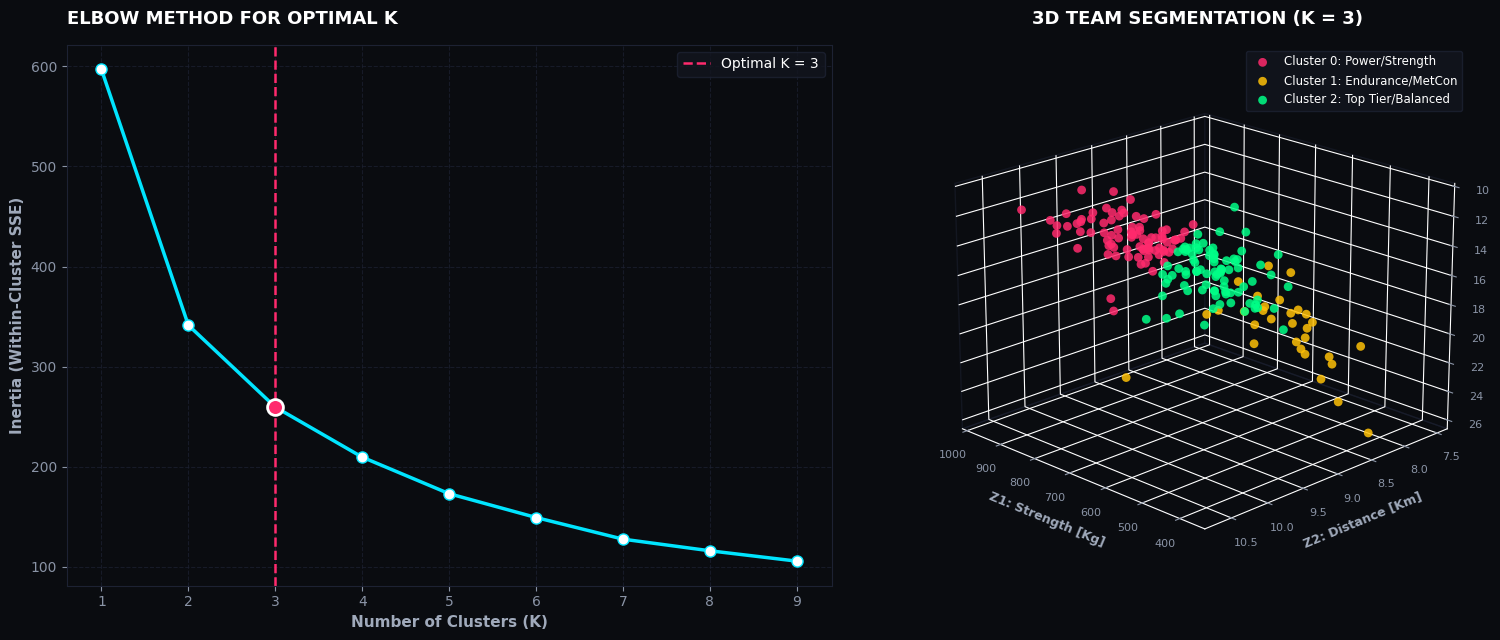

In [ ]:
# @title CODE: Cluster Analysis 1

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data & Scale
features = ['Zone_1_tot', 'Zone_2_tot', 'MetCon_Min']
df_ml = df.dropna(subset=features).copy()
X = df_ml[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Elbow Calculation
k_range = range(1, 10)
inertias = [
    KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
    for k in k_range
]

# 3. Fit Optimal K-Means (K=3)
optimal_k = 3
kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_ml['Cluster'] = kmeans_opt.fit_predict(X_scaled)

# 4. Render Split Dashboard (2D Elbow + 3D Cluster Projection)
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 6.5), facecolor='#0A0C10')

# --- LEFT: ELBOW METHOD (2D) ---
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_facecolor('#0A0C10')
ax1.plot(
    list(k_range),
    inertias,
    marker='o',
    markersize=8,
    color='#00E5FF',
    linewidth=2.5,
    markerfacecolor='#FFFFFF',
    markeredgecolor='#00E5FF',
)
ax1.axvline(
    x=optimal_k,
    color='#FF2A6D',
    linestyle='--',
    linewidth=1.8,
    label=f'Optimal K = {optimal_k}',
)
ax1.scatter(
    [optimal_k],
    [inertias[optimal_k - 1]],
    color='#FF2A6D',
    s=130,
    zorder=5,
    edgecolor='#FFFFFF',
    linewidth=2,
)

ax1.set_title(
    'ELBOW METHOD FOR OPTIMAL K',
    color='#FFFFFF',
    fontsize=13,
    weight='bold',
    loc='left',
    pad=15,
)
ax1.set_xlabel(
    'Number of Clusters (K)', color='#A0AABB', fontsize=11, weight='bold'
)
ax1.set_ylabel(
    'Inertia (Within-Cluster SSE)', color='#A0AABB', fontsize=11, weight='bold'
)
ax1.set_xticks(list(k_range))
ax1.grid(True, color='#1D2233', linestyle='--', alpha=0.7)
ax1.tick_params(colors='#8A94A6', labelsize=10)
ax1.legend(facecolor='#12151F', edgecolor='#1D2233', labelcolor='white')

# --- RIGHT: 3D CLUSTER SCATTER PLOT ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.set_facecolor('#0A0C10')

# Custom dark theme panes for 3D axis
ax2.xaxis.pane.fill = False
ax2.yaxis.pane.fill = False
ax2.zaxis.pane.fill = False
ax2.xaxis.pane.set_edgecolor('#1D2233')
ax2.yaxis.pane.set_edgecolor('#1D2233')
ax2.zaxis.pane.set_edgecolor('#1D2233')

cluster_colors = ['#FF2A6D', '#FFC107', '#00FF87']
cluster_names = [
    'Cluster 0: Power/Strength',
    'Cluster 1: Endurance/MetCon',
    'Cluster 2: Top Tier/Balanced',
]

for cluster_id in range(optimal_k):
  subset = df_ml[df_ml['Cluster'] == cluster_id]
  ax2.scatter(
      subset['Zone_1_tot'],
      subset['Zone_2_tot'],
      subset['MetCon_Min'],
      color=cluster_colors[cluster_id],
      label=cluster_names[cluster_id],
      alpha=0.85,
      s=40,
      edgecolor='none',
  )

ax2.set_title(
    f'3D TEAM SEGMENTATION (K = {optimal_k})',
    color='#FFFFFF',
    fontsize=13,
    weight='bold',
    pad=15,
)
ax2.set_xlabel('Z1: Strength [Kg]', color='#A0AABB', fontsize=9, weight='bold')
ax2.set_ylabel('Z2: Distance [Km]', color='#A0AABB', fontsize=9, weight='bold')
ax2.set_zlabel('Z3: MetCon [Min]', color='#A0AABB', fontsize=9, weight='bold')

# Invert Z axis so lower time (better performance in MetCon) goes upward
ax2.invert_zaxis()

ax2.tick_params(colors='#8A94A6', labelsize=8)
ax2.legend(
    facecolor='#12151F',
    edgecolor='#1D2233',
    labelcolor='white',
    loc='upper right',
    fontsize=8.5,
)

# Set optimal viewing angle
ax2.view_init(elev=20, azim=135)

for spine in ax1.spines.values():
  spine.set_color('#1D2233')

plt.tight_layout()
plt.show()

In [ ]:
# Calcolo delle medie fisiche per ciascun cluster
cluster_summary = (
    df_ml.groupby('Cluster')[['Zone_1_tot', 'Zone_2_tot', 'MetCon_Min', 'rank']]
    .mean()
    .reset_index()
)
print(cluster_summary)

   Cluster  Zone_1_tot  Zone_2_tot  MetCon_Min        rank
0        0  779.011905    9.640274   13.357540   42.702381
1        1  600.866667    8.344400   20.365000  178.700000
2        2  642.717647    9.127682   15.606471  128.847059


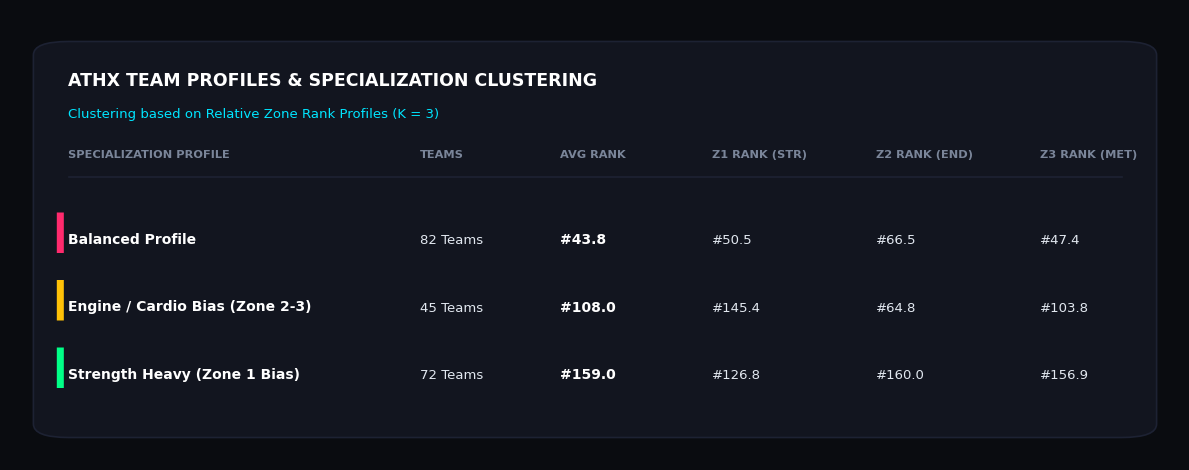

In [ ]:
# @title CODE: Cluster Analysis 2

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. PREPARE DATA USING PARTIAL RANKS INSTEAD OF ABSOLUTE VALUES
df_ml = df.copy()

# Ranks (1-based: lower is better)
df_ml['r1'] = df_ml['Zone_1_tot'].rank(ascending=False, method='min')
df_ml['r2'] = df_ml['Zone_2_tot'].rank(ascending=False, method='min')
df_ml['r3'] = df_ml['MetCon_Min'].rank(ascending=True, method='min')

rank_features = ['r1', 'r2', 'r3']
X_ranks = df_ml[rank_features].values

# Standardize rank profiles
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ranks)

# 2. FIT K-MEANS WITH K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['Profile_Cluster'] = kmeans.fit_predict(X_scaled)

# 3. IDENTIFY CLUSTER PROFILES BASED ON ZONE DIFFERENCES
cluster_profiles = df_ml.groupby('Profile_Cluster')[
    ['r1', 'r2', 'r3', 'rank']
].mean()


# Function to dynamically map profiles
def assign_profile_label(row):
  r1, r2, r3 = row['r1'], row['r2'], row['r3']
  min_rank_zone = min(r1, r2, r3)

  if min_rank_zone == r1 and (r2 - r1 > 15 or r3 - r1 > 15):
    return 'Strength Heavy (Zone 1 Bias)'
  elif (min_rank_zone == r2 or min_rank_zone == r3) and (
      r1 - min(r2, r3) > 15
  ):
    return 'Engine / Cardio Bias (Zone 2-3)'
  else:
    return 'Balanced Profile'


# Generate custom labels based on group rank averages
labels_map = {}
for c_id, row in cluster_profiles.iterrows():
  labels_map[c_id] = assign_profile_label(row)

df_ml['Profile_Name'] = df_ml['Profile_Cluster'].map(labels_map)

# 4. RENDER VISUAL SUMMARY CARD FOR PROFILES
summary_table = (
    df_ml.groupby('Profile_Name')
    .agg(
        Teams=('team', 'count'),
        Avg_Overall_Rank=('rank', 'mean'),
        Avg_Z1_Rank=('r1', 'mean'),
        Avg_Z2_Rank=('r2', 'mean'),
        Avg_Z3_Rank=('r3', 'mean'),
    )
    .reset_index()
)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 4.8), facecolor='#0A0C10')
ax.set_facecolor('#0A0C10')

container = patches.FancyBboxPatch(
    (0.02, 0.05),
    0.96,
    0.88,
    boxstyle='round,pad=0,rounding_size=0.03',
    facecolor='#12151F',
    edgecolor='#1D2233',
    linewidth=1.2,
    transform=ax.transAxes,
)
ax.add_patch(container)

ax.text(
    0.05,
    0.83,
    'ATHX TEAM PROFILES & SPECIALIZATION CLUSTERING',
    color='#FFFFFF',
    fontsize=12.5,
    fontweight='bold',
    transform=ax.transAxes,
)
ax.text(
    0.05,
    0.76,
    'Clustering based on Relative Zone Rank Profiles (K = 3)',
    color='#00E5FF',
    fontsize=9.5,
    transform=ax.transAxes,
)

headers = [
    'SPECIALIZATION PROFILE',
    'TEAMS',
    'AVG RANK',
    'Z1 RANK (STR)',
    'Z2 RANK (END)',
    'Z3 RANK (MET)',
]
col_x = [0.05, 0.35, 0.47, 0.60, 0.74, 0.88]

for j, h in enumerate(headers):
  ax.text(
      col_x[j],
      0.67,
      h,
      color='#7A8599',
      fontsize=8.2,
      fontweight='bold',
      transform=ax.transAxes,
  )

ax.plot(
    [0.05, 0.95],
    [0.63, 0.63],
    color='#1D2233',
    linewidth=1.2,
    transform=ax.transAxes,
)

colors = ['#FF2A6D', '#FFC107', '#00FF87']
y_start = 0.48
y_step = 0.15

for idx, row in summary_table.iterrows():
  y = y_start - (idx * y_step)

  bar = patches.FancyBboxPatch(
      (0.04, y - 0.02),
      0.006,
      0.09,
      boxstyle='round,pad=0',
      facecolor=colors[idx % len(colors)],
      linewidth=0,
      transform=ax.transAxes,
  )
  ax.add_patch(bar)

  ax.text(
      col_x[0],
      y,
      row['Profile_Name'],
      color='#FFFFFF',
      fontsize=10,
      fontweight='bold',
      transform=ax.transAxes,
  )
  ax.text(
      col_x[1],
      y,
      f"{int(row['Teams'])} Teams",
      color='#E2E8F0',
      fontsize=9.5,
      transform=ax.transAxes,
  )
  ax.text(
      col_x[2],
      y,
      f"#{row['Avg_Overall_Rank']:.1f}",
      color='#FFFFFF',
      fontsize=10,
      fontweight='bold',
      transform=ax.transAxes,
  )
  ax.text(
      col_x[3],
      y,
      f"#{row['Avg_Z1_Rank']:.1f}",
      color='#E2E8F0',
      fontsize=9.5,
      transform=ax.transAxes,
  )
  ax.text(
      col_x[4],
      y,
      f"#{row['Avg_Z2_Rank']:.1f}",
      color='#E2E8F0',
      fontsize=9.5,
      transform=ax.transAxes,
  )
  ax.text(
      col_x[5],
      y,
      f"#{row['Avg_Z3_Rank']:.1f}",
      color='#E2E8F0',
      fontsize=9.5,
      transform=ax.transAxes,
  )

ax.axis('off')
plt.tight_layout()
plt.show()